### PMSM 2D Steady-State

- 6 slot and 4 poles
- 3phase currents
- Solving with vector potential A

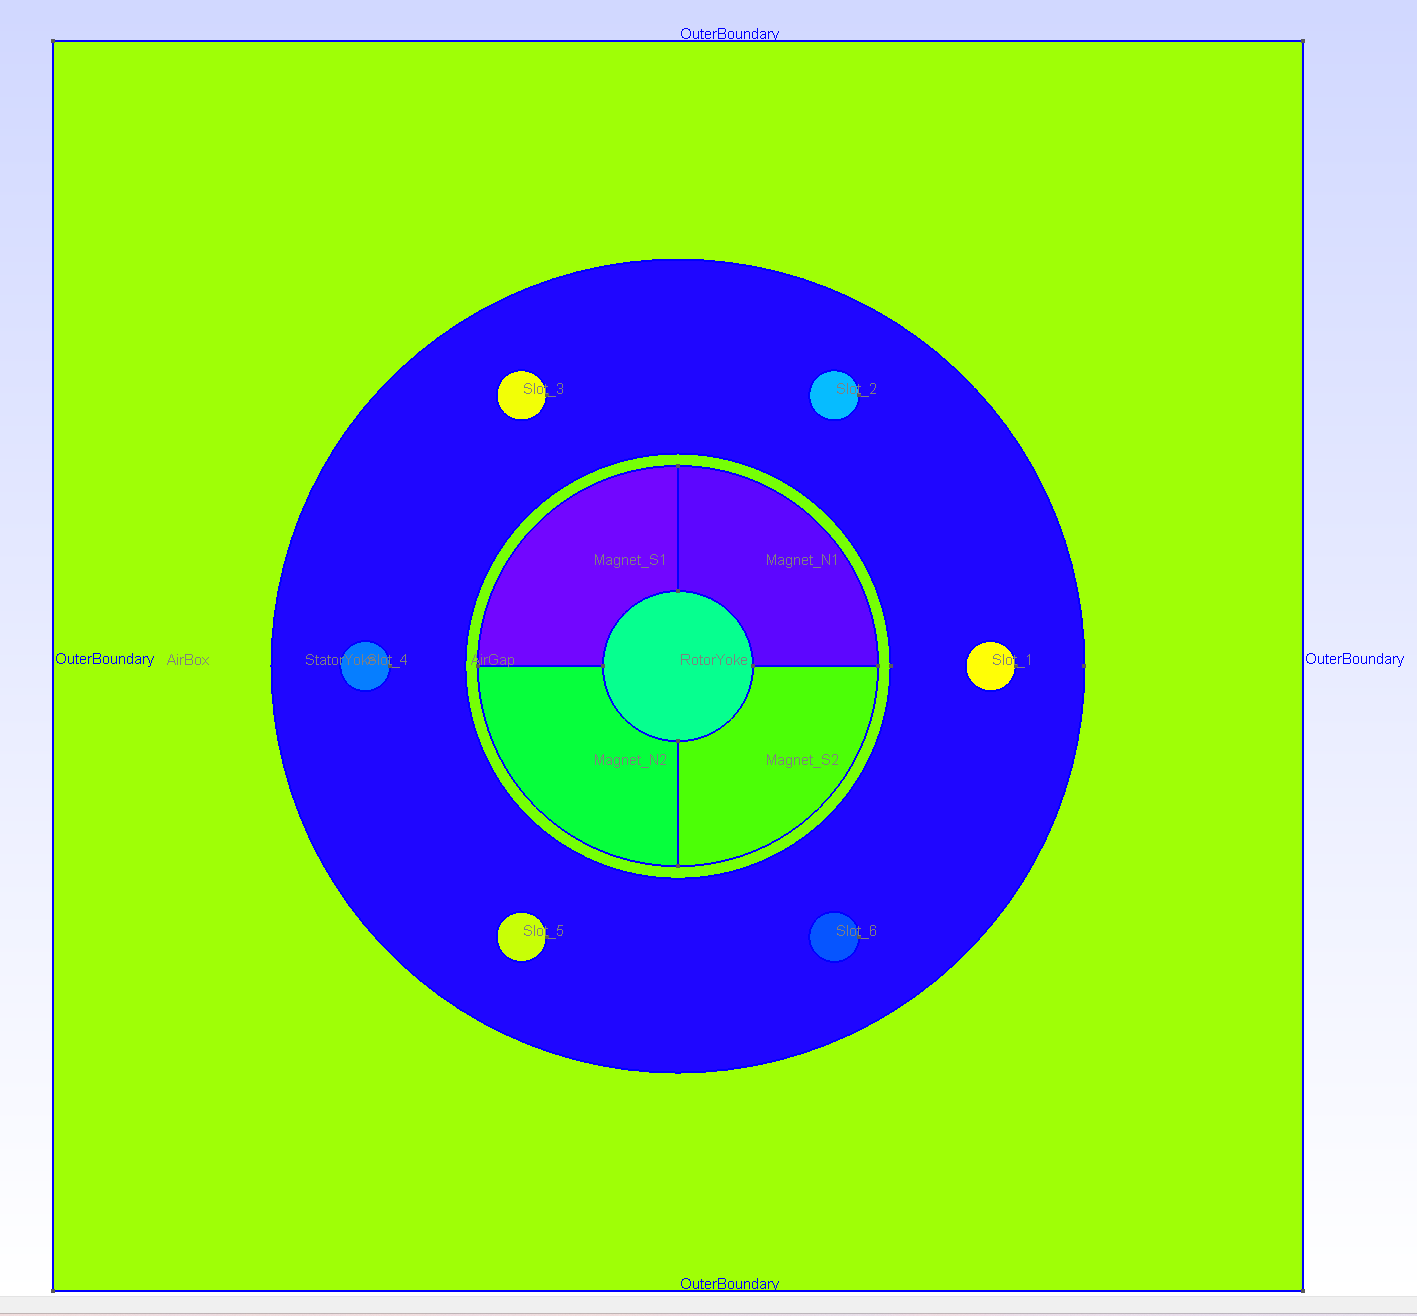

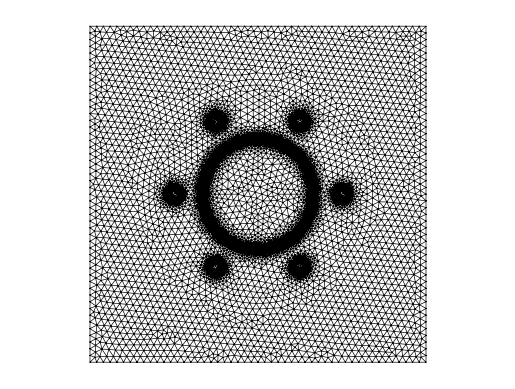

In [3]:
import meshio
from skfem import *
from skfem.helpers import dot, grad
import numpy as np

from skfem.io.meshio import from_meshio

# Add repository root to Python path. Helps to find files and modules
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent))


m = meshio.read("mesh/mesh_ex6.msh")

mesh = from_meshio(m)

from skfem.visuals.matplotlib import draw
import matplotlib.pyplot as plt

import matplotlib.tri as mtri

draw(mesh)
plt.axis("equal")
plt.show()



Define basis for each region

In [4]:
from skfem import Basis, ElementTriP1

e = ElementTriP1()
basis = Basis(mesh, e)

basis_rotor_yoke = basis.with_elements(mesh.subdomains["RotorYoke"])
basis_stator_yoke = basis.with_elements(mesh.subdomains["StatorYoke"])
basis_air_box = basis.with_elements(mesh.subdomains["AirBox"])
basis_air_gap = basis.with_elements(mesh.subdomains["AirGap"])

basis_magnet_N1 = basis.with_elements(mesh.subdomains["Magnet_N1"])
basis_magnet_S1 = basis.with_elements(mesh.subdomains["Magnet_S1"])
basis_magnet_N2 = basis.with_elements(mesh.subdomains["Magnet_N2"])
basis_magnet_S2 = basis.with_elements(mesh.subdomains["Magnet_S2"])

In [5]:

# Slot to phzse current mapping
"""
Slot_1 → A+
Slot_2 → B−
Slot_3 → C+
Slot_4 → A−
Slot_5 → B+
Slot_6 → C−
"""

slot_bases = [
    basis.with_elements(mesh.subdomains[f"Slot_{i}"])
    for i in range(1, 7)
]

# For example Slot_1 → A+
print(slot_bases[0])

# Evaluate slot area for to solve the current denisty
# Test winding area
from skfem import Functional
@Functional
def area(w):
    return 1.0

print()
slot_area = area.assemble(slot_bases[0]) 
print("In units of m: ", slot_area)

<skfem CellBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 248
  Number of DOFs: 9825
  Size: 53568 B

In units of m:  5.007820143519462e-05


In [6]:
mu0 = 4 * np.pi * 1e-7
mu_air = mu0
mu_pm = mu0
mu_iron = 1000 * mu0
# w.mu little confusing but it just wraps the permeability to some variable w
@BilinearForm
def laplace(A, v, w):
    return 1/w.mu*dot(grad(A), grad(v))

I_0 = 0
f = 50
omega = 2*np.pi*f
t = 0  # lets keep now only one time moment, later we can loop this

I_A = I_0*np.cos(omega*t)
I_B = I_0*np.cos(omega*t - 2*np.pi/3)
I_C = I_0*np.cos(omega*t - 4*np.pi/3)

J_A = I_A / slot_area
J_B = I_B / slot_area
J_C = I_C / slot_area
@LinearForm
def slot_rhs(v, w):
    return w.J * v

Br = 1.2 # Remanence 
@LinearForm
def magnet_rhs(v, w):
    Brx = w.Brx
    Bry = w.Bry
    mu = w.mu  

    return 1/mu * (
        Brx * v.grad[1]
        -
        Bry * v.grad[0]
    )

# Assemble left hand side. We have linear materials, so just change permeability

# RotorYoke and StatorYoke are modelled as magnetic iron
S_mat = laplace.assemble(basis_rotor_yoke, mu=mu_iron)
S_mat += laplace.assemble(basis_stator_yoke, mu=mu_iron)

# Other parts are modelled as non magnetic
S_mat += laplace.assemble(basis_air_box, mu=mu_air)
S_mat += laplace.assemble(basis_air_gap, mu=mu_air)
# Magnets have remanence, but are not getting magnetized by other fields
S_mat += laplace.assemble(basis_magnet_N1, mu=mu_air)
S_mat += laplace.assemble(basis_magnet_S1, mu=mu_air)
S_mat += laplace.assemble(basis_magnet_N2, mu=mu_air)
S_mat += laplace.assemble(basis_magnet_S2, mu=mu_air)

# Slots (air-filled)
for basis_i in slot_bases:
    S_mat += laplace.assemble(basis_i, mu=mu_air)

# Assemble right hand side for slots. Add current density source to each slot. We use 3phase currents
b =  slot_rhs.assemble(slot_bases[0], J = +J_A)
b +=  slot_rhs.assemble(slot_bases[1], J = -J_B)
b +=  slot_rhs.assemble(slot_bases[2], J = +J_C)
b +=  slot_rhs.assemble(slot_bases[3], J = -J_A)
b +=  slot_rhs.assemble(slot_bases[4], J = +J_B)
b +=  slot_rhs.assemble(slot_bases[5], J = -J_C)


# Assemble right hand side for magnets. These are the remanence source, they behave as current sources in wea form.

# We want to magnetize magnet radially, so we need their x,y coordinates. Then we can compute the radial direction

# MAGNET NORTH 1
x = basis_magnet_N1.global_coordinates().value[0]
y = basis_magnet_N1.global_coordinates().value[1]

r = np.sqrt(x**2 + y**2)

Brx = Br * x / r
Bry = Br * y / r

# Keep the direction of magnetization positive for north poles
b += magnet_rhs.assemble(
    basis_magnet_N1,
    Brx=Brx,
    Bry=Bry,
    mu=mu_pm,
)

# MAGNET SOUTH  1
x = basis_magnet_S1.global_coordinates().value[0]
y = basis_magnet_S1.global_coordinates().value[1]

r = np.sqrt(x**2 + y**2)

Brx = Br * x / r
Bry = Br * y / r

# Reverse the direction of magnetization for south poles
b += magnet_rhs.assemble(
    basis_magnet_S1,
    Brx=-Brx,
    Bry=-Bry,
    mu=mu_pm,
)

# MAGNET NORTH  2
x = basis_magnet_N2.global_coordinates().value[0]
y = basis_magnet_N2.global_coordinates().value[1]

r = np.sqrt(x**2 + y**2)

Brx = Br * x / r
Bry = Br * y / r

b += magnet_rhs.assemble(
    basis_magnet_N2,
    Brx=Brx,
    Bry=Bry,
    mu=mu_pm,
)


# MAGNET SOUTH 2
x = basis_magnet_S2.global_coordinates().value[0]
y = basis_magnet_S2.global_coordinates().value[1]

r = np.sqrt(x**2 + y**2)

Brx = Br * x / r
Bry = Br * y / r

# Reverse the direction of magnetization for south poles
b += magnet_rhs.assemble(
    basis_magnet_S2,
    Brx=-Brx,
    Bry=-Bry,
    mu=mu_pm,
)


Next we add A_z=0 on the airbox boundaries and solve the linear system

In [7]:
S_mat, b = enforce(S_mat, b, D=mesh.boundary_nodes())

A_z = solve(S_mat, b)

Visualize solved vector potential

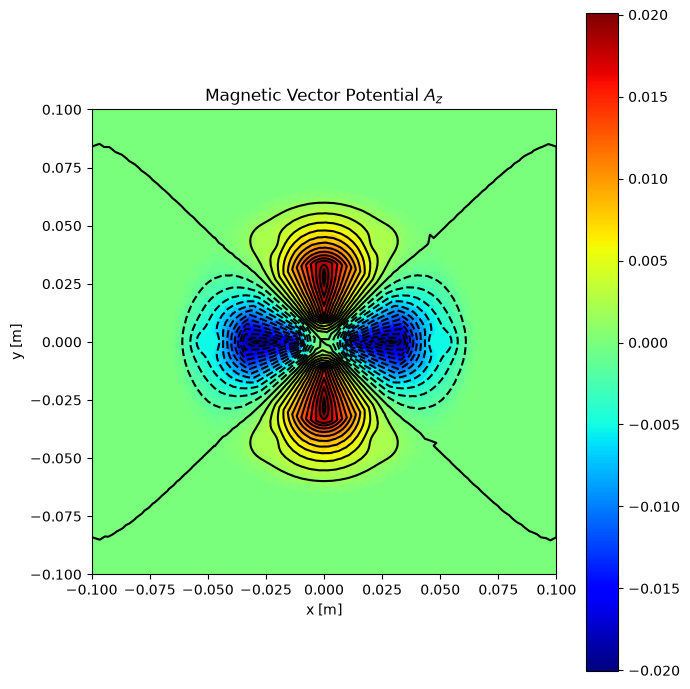

In [8]:
import matplotlib.pyplot as plt
from skfem.visuals.matplotlib import plot

fig, ax = plt.subplots(figsize=(7,7))


plot(
    mesh,
    A_z,
    shading="gouraud",
    colorbar=True,
    ax=ax,
)

plot(
    mesh,
    A_z,
    ax=ax,
    levels=30,
    color="black",
    linewidths=0.4,
)

ax.set_aspect("equal")
ax.set_title(r"Magnetic Vector Potential $A_z$")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")

plt.tight_layout()
#from skfem.visuals.matplotlib import draw

#draw(mesh, ax=ax)


Now we compute Bx and By with partial derivatives to plot B field

In [9]:

# basis.interpolate(A_z) creates a finite element function Ah = sum(Ni*Ai)   ,  where Ni is shape function and Ai is nodal vectorpotential values
uh = basis.interpolate(A_z)

# grad object has the dA/dx and dA/dy components
dAz_dx = uh.grad[0]
dAz_dy = uh.grad[1]

Bx = dAz_dy
By = -dAz_dx

# each quanrature point  has own gradient (P1 elem should have constant gradient) This way we collpase this into one gradient value per element
Bx_elem = Bx.mean(axis=1)
By_elem = By.mean(axis=1)

Bnorm_elem = np.sqrt(Bx_elem**2 + By_elem**2)

mesh.p: (2, 9825)
mesh.t: (3, 19448)
centers: (2, 19448)
Bx_plot: (19448,)


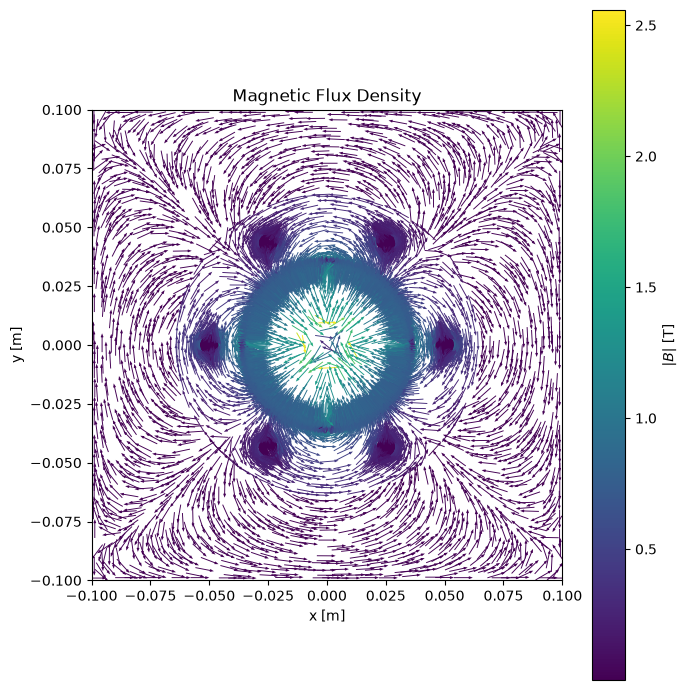

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Element connectivity
# Coordinates of the three vertices of every element
x = mesh.p[0, mesh.t]   # shape: (3, nelements)
y = mesh.p[1, mesh.t]   # shape: (3, nelements)

# Element centroids
centers = np.vstack([
    x.mean(axis=0),
    y.mean(axis=0)
])


eps = 1e-14

Bx_plot = Bx_elem / (Bnorm_elem + eps)
By_plot = By_elem / (Bnorm_elem + eps)

fig, ax = plt.subplots(figsize=(7,7))

step = 2
print("mesh.p:", mesh.p.shape)
print("mesh.t:", mesh.t.shape)
print("centers:", centers.shape)
print("Bx_plot:", Bx_plot.shape)
q = ax.quiver(
    centers[0][::step],
    centers[1][::step],
    Bx_plot[::step],
    By_plot[::step],
    Bnorm_elem[::step],
    cmap="viridis",
    pivot="mid",
    scale=25,
    width=0.002,
    headwidth=3,
    headlength=4
)

fig.colorbar(q, ax=ax, label=r"$|B|$ [T]")

# Zoom into the region around the C-core
xmin, ymin = mesh.p.min(axis=1)
xmax, ymax = mesh.p.max(axis=1)
d = max(xmax - xmin, ymax - ymin)

margin = 0.0 * d  # CHANGE TO ZOOM

ax.set_xlim(xmin + margin, xmax - margin)
ax.set_ylim(ymin + margin, ymax - margin)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_aspect("equal")

ax.set_title("Magnetic Flux Density")

plt.tight_layout()

### Plotting B for each node
Compute B for each node instead of element.
The gradient is constant in P1 elementents, and is not continious over elements. We have to do some averaging, if node that shares multiple elements have different gradient values.

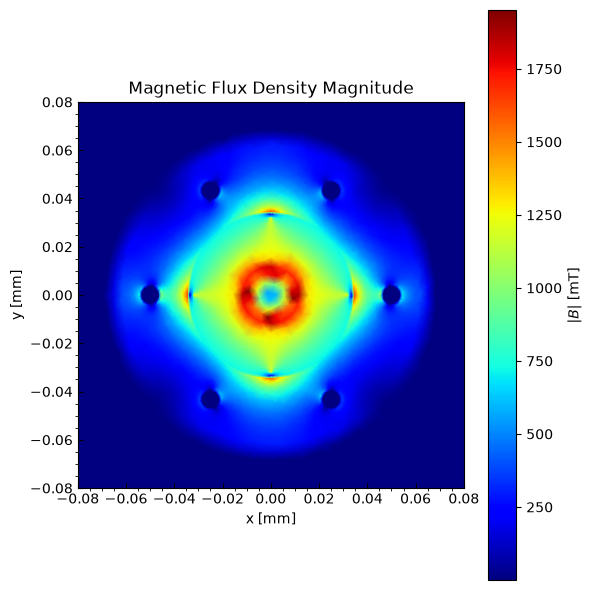

In [11]:
import matplotlib.pyplot as plt
import matplotlib.tri as mtri


triang = mtri.Triangulation(
    mesh.p[0],
    mesh.p[1],
    mesh.t.T
)

# convert element values to nodal values
Bnorm_node = np.zeros(mesh.p.shape[1])
count = np.zeros(mesh.p.shape[1])

for elem, tri in enumerate(mesh.t.T):
    for node in tri:
        Bnorm_node[node] += Bnorm_elem[elem]
        count[node] += 1

# B is constant over each element. Nodal values require averaging
Bnorm_node /= count

fig, ax = plt.subplots(figsize=(6, 6))

plot(
    mesh,
    1000 * Bnorm_node,
    ax=ax,
    shading='gouraud',
    colorbar=True
)

# Zoom into the region around the C-core
xmin, ymin = mesh.p.min(axis=1)
xmax, ymax = mesh.p.max(axis=1)
d = max(xmax - xmin, ymax - ymin)
margin = 0.1 * d  # CHANGE TO ZOOM
ax.set_xlim(xmin + margin, xmax - margin)
ax.set_ylim(ymin + margin, ymax - margin)

ax.set_title("Magnetic Flux Density Magnitude")
ax.set_xlabel("x [mm]")
ax.set_ylabel("y [mm]")
ax.set_aspect("equal")

ax.tick_params(direction='in')
ax.minorticks_on()

# Label the colorbar
cbar = fig.axes[-1]
cbar.set_ylabel(r"$|B|$ [mT]")

fig.tight_layout()
#draw(mesh, ax=ax)

plt.show()

In [19]:
import numpy as np

# Skip all comment lines starting with %
data = np.loadtxt(
    "verification/A_field.txt",
    comments="%"
)

# Split columns
points = data[:, :2]*1e-3 # # Points units are mm -> convert to meters
Az_comsol = data[:, 2]    # (N,)


from utils.field_verification import L2_verify

L2_verify(
    A_z,
    Az_comsol,
    basis,
    quantity_name="A_z",
)

ImportError: cannot import name 'L2_verify' from 'utils.field_verification' (c:\Users\vertta\Documents\compmag\utils\field_verification.py)

Lets check that results agree with comsol!

In [ ]:
import numpy as np

# Skip all comment lines starting with %
data = np.loadtxt(
    "verification/A_field.txt",
    comments="%"
)

# Split columns
points = data[:, :2]*1e-3 # # Points units are mm -> convert to meters
Az_comsol = data[:, 2]    # (N,)

from utils.field_verification import compare_point_values
# Unit in our of fem Wb/m
compare_point_values(
    basis,
    A_z,
    points,
    Az_comsol,
    quantity_name="A_z"
);

ImportError: cannot import name 'L2_verify' from 'utils.field_verification' (c:\Users\vertta\Documents\compmag\utils\field_verification.py)

Az has small mean relative error, but has some big values. Az is only helping us to compute B, so lets see are these better

In [ ]:
# Skip all comment lines starting with %
data = np.loadtxt(
    "verification/B_field.txt",
    comments="%"
)

# Split columns
points = data[:, :2]*1e-3      # (N,2)
B_comsol = data[:, 2]    # (N,)

from utils.field_verification import compare_point_values

# Units match for B since gradients not care about is it meters or millimeters
compare_point_values(
    basis,
    Bnorm_node,
    points,
    B_comsol,
    quantity_name="B_field"
);

      x       y            FEM      Reference     Abs. Error   Rel. Error %
--------------------------------------------------------------------------------
 -0.090 -0.090   1.561942e-06   1.084050e-06   4.778918e-07         44.084
 -0.070 -0.090   1.313242e-05   1.350722e-05   3.748039e-07          2.775
 -0.050 -0.090   4.762653e-05   4.642988e-05   1.196649e-06          2.577
 -0.030 -0.090   1.029464e-04   9.900964e-05   3.936771e-06          3.976
 -0.010 -0.090   1.508432e-04   1.500739e-04   7.693102e-07          0.513
  0.010 -0.090   1.510019e-04   1.510487e-04   4.683389e-08          0.031
  0.030 -0.090   1.031302e-04   1.020328e-04   1.097413e-06          1.076
  0.050 -0.090   4.716817e-05   4.443379e-05   2.734379e-06          6.154
  0.070 -0.090   1.321493e-05   1.447207e-05   1.257145e-06          8.687
  0.090 -0.090   1.589249e-06   1.518538e-06   7.071049e-08          4.656
 -0.090 -0.070   9.713691e-06   1.047524e-05   7.615513e-07          7.270
 -0.070 -0.070   2

B-field is differing only 1.1% on average and maximum error only 10%

Lets compute the Torque with Arkkios method. In 2D we must do surface integral over airgap

In [ ]:
import numpy as np
from skfem import Functional

mu0 = 4 * np.pi * 1e-7
L_stack = 1.0        # your machine's axial stack length
airgap_thickess = 2*1e-3 ## 2mm airgap          # inner/outer radius of the AirGap annulus

@Functional
def arkkio_integrand(w):
    gradA = w['A'].grad           # shape (2, nelems, nqp): [dA/dx, dA/dy]
    Bx = gradA[1]
    By = -gradA[0]

    x, y = w.x                    # global coordinates at quadrature points
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)

    Br = Bx * np.cos(theta) + By * np.sin(theta)
    Bt = -Bx * np.sin(theta) + By * np.cos(theta)

    return r * Br * Bt

integral = arkkio_integrand.assemble(
    basis_air_gap, A=basis_air_gap.interpolate(A_z)
)

torque = (L_stack / (mu0 * (airgap_thickess))) * integral

print("Claude Torque: ", torque)


import numpy as np

x, y = basis_air_gap.global_coordinates().value
r = np.sqrt(x**2 + y**2)

gradA = basis_air_gap.interpolate(A_z).grad
Bx, By = gradA[1], -gradA[0]
theta = np.arctan2(y, x)
Br = Bx*np.cos(theta) + By*np.sin(theta)
Bt = -Bx*np.sin(theta) + By*np.cos(theta)

integrand = r * Br * Bt   # per quadrature point, shape (nelems, nqp)

# bin by radius and look at the profile
r_flat = r.flatten()
val_flat = integrand.flatten()
for lo, hi in zip(np.linspace(r.min(), r.max(), 6)[:-1], np.linspace(r.min(), r.max(), 6)[1:]):
    mask = (r_flat >= lo) & (r_flat < hi)
    print(f"r in [{lo:.4f},{hi:.4f}]: mean integrand = {val_flat[mask].mean():.3e}, n_pts={mask.sum()}")


Claude Torque:  0.0011688152437410023
r in [0.0320,0.0324]: mean integrand = -4.366e-06, n_pts=3023
r in [0.0324,0.0328]: mean integrand = -2.585e-06, n_pts=3696
r in [0.0328,0.0332]: mean integrand = -3.065e-06, n_pts=2749
r in [0.0332,0.0336]: mean integrand = 1.743e-06, n_pts=3697
r in [0.0336,0.0340]: mean integrand = 2.646e-07, n_pts=3334


In [ ]:
from skfem import Functional
import numpy as np
airgap_thickess = 2*1e-3 ## 2mm airgap
l = 1 # This is essentially torque / meter
prefactor = l / (mu0 * airgap_thickess)

uh_gap = basis_air_gap.interpolate(A_z)

Bx_gap = uh_gap.grad[1]
By_gap = -uh_gap.grad[0]

@Functional
def arkkio(w):
    x = w.x[0]
    y = w.x[1]

    rr = np.sqrt(x**2 + y**2) + 1e-15   # avoid division by zero

    Br = (x*w.Bx + y*w.By) / rr  # Radial component of B
    Bt = (-y*w.Bx + x*w.By) / rr # Angular component of B

    return prefactor * Br * Bt * rr

airgap_elements = mesh.subdomains["AirGap"]
Bx_airgap = Bx[airgap_elements]
By_airgap = By[airgap_elements]

T = arkkio.assemble(
    basis_air_gap,
    Bx=Bx_gap,
    By=By_gap,
)

print("Arkkio's torque: ", T)

IndexError: index 13318 is out of bounds for axis 0 with size 2750

Check the airgap valeus , if the torque can even be correct

In [ ]:
# Skip all comment lines starting with %
data = np.loadtxt(
    "verification/B_field_airgap.txt",
    comments="%"
)

# Split columns
points = data[:, :2]*1e-3      # (N,2)
B_comsol = data[:, 2]    # (N,)

from utils.field_verification import compare_point_values

# Units match for B since gradients not care about is it meters or millimeters
compare_point_values(
    basis,
    Bnorm_node,
    points,
    B_comsol,
    quantity_name="B_airgap_noload"
);

      x       y            FEM      Reference     Abs. Error   Rel. Error %
--------------------------------------------------------------------------------
  0.033  0.000   3.913490e-01   3.326664e-01   5.868265e-02         17.640
 -0.028 -0.018   7.316060e-01   7.323502e-01   7.441607e-04          0.102
  0.013  0.030   7.413051e-01   7.426396e-01   1.334473e-03          0.180
  0.005 -0.033   7.154045e-01   7.192412e-01   3.836723e-03          0.533
 -0.022  0.025   7.269461e-01   7.276933e-01   7.471550e-04          0.103
  0.032 -0.009   7.466264e-01   7.476049e-01   9.784448e-04          0.131
 -0.031 -0.010   7.469171e-01   7.474921e-01   5.749734e-04          0.077
  0.021  0.026   7.276020e-01   7.282428e-01   6.408132e-04          0.088
 -0.004 -0.033   6.704084e-01   6.809129e-01   1.050448e-02          1.543
 -0.015  0.030   7.385016e-01   7.396043e-01   1.102677e-03          0.149
  0.028 -0.017   7.341309e-01   7.344990e-01   3.681196e-04          0.050
 -0.033 -0.001   5